In [19]:
from langgraph.graph import StateGraph, START, END
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [20]:
# model configureation and testing

model = ChatOpenRouter(model ="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free", temperature=0.5)

res = model.invoke("what is llm")

print(res.content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


**LLM** stands for **Large Language Model**.

### What a Large Language Model Is
- **Definition**: A large language model is a type of artificial‑intelligence system that has been trained on massive amounts of text data to predict the next word (or token) in a sequence. By learning statistical patterns in language, it can generate coherent, context‑aware text, answer questions, translate languages, summarize content, and perform many other language‑related tasks.
- **Key Characteristics**:
  1. **Scale**: “Large” refers to two main dimensions:
     - **Parameter count** – the number of learned weights (e.g., millions, billions, or even trillions). More parameters generally give the model greater capacity to capture nuanced patterns.
     - **Training data** – the volume and diversity of text the model sees during training (books, articles, webpages, code, etc.).
  2. **Architecture**: Most modern LLMs use the **Transformer** architecture (introduced in 2017). Transformers rely on self‑

In [21]:
# state

class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    

In [22]:
# create node

def create_outline(state: BlogState) -> BlogState:
    # fetch title
    title = state['title']
    
    # call llm model
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content
    
    # update state
    state['outline'] = outline
    
    return state

def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    
    prompt = f"write a detailed blog on the title - {title} with using the following outline {outline}"
    content = model.invoke(prompt).content
    
    state['content'] = content
    
    return state

In [23]:
# defind and compile Graph

graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [24]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'title': 'Rise of AI in India', 'outline': '**Blog Title:** *The Rise of Artificial Intelligence in India – Trends, Impact, and the Road Ahead*  \n\n---\n\n## 1. Introduction  \n- **Hook:** A striking statistic (e.g., “AI‑driven startups in India grew 300% YoY in 2023”).  \n- **Why it matters:** AI’s potential to transform the Indian economy, society, and geopolitical standing.  \n- **Thesis statement:** The rapid adoption of AI in India is being propelled by favorable policies, a burgeoning talent pool, and sector‑specific demand; however, challenges around data, ethics, and infrastructure must be addressed for sustainable growth.\n\n---\n\n## 2. Historical Context & Current Landscape  \n### 2.1 Early Beginnings  \n- 1990s–2000s: Limited research, academic collaborations (IITs, IISc).  \n- 2010‑2015: Emergence of data‑centric startups (e.g., Niramai, Stellr).  \n\n### 2.2 Recent Surge (2015‑2024)  \n- Explosion of AI patents & publications from Indian institutions.  \n- Venture capit

In [25]:
print(final_state['outline'])

**Blog Title:** *The Rise of Artificial Intelligence in India – Trends, Impact, and the Road Ahead*  

---

## 1. Introduction  
- **Hook:** A striking statistic (e.g., “AI‑driven startups in India grew 300% YoY in 2023”).  
- **Why it matters:** AI’s potential to transform the Indian economy, society, and geopolitical standing.  
- **Thesis statement:** The rapid adoption of AI in India is being propelled by favorable policies, a burgeoning talent pool, and sector‑specific demand; however, challenges around data, ethics, and infrastructure must be addressed for sustainable growth.

---

## 2. Historical Context & Current Landscape  
### 2.1 Early Beginnings  
- 1990s–2000s: Limited research, academic collaborations (IITs, IISc).  
- 2010‑2015: Emergence of data‑centric startups (e.g., Niramai, Stellr).  

### 2.2 Recent Surge (2015‑2024)  
- Explosion of AI patents & publications from Indian institutions.  
- Venture capital inflow: > $7 billion in AI‑related funding (2023).  
- Growt

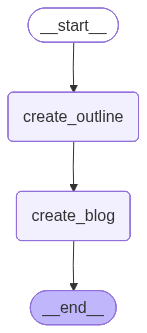

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [26]:

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())